# Case 3: our dynamic estimator vs official DYNOTEARS
Interactive debugger: one simulation is shared by truth, our estimator, and the isolated official CausalNex DYNOTEARS worker.

In [1]:
from pathlib import Path
import sys, numpy as np, matplotlib.pyplot as plt
from IPython.display import display
ROOT=Path.cwd().resolve(); ROOT=ROOT.parent if ROOT.name=='notebooks' else ROOT
sys.path.insert(0,str(ROOT/'src'))
from causal_opt.simulation import simulate_svar
from causal_opt.methods.dynamic_latent import fit_dynamic_latent
from causal_opt.baselines.dynotears import fit_dynotears
from causal_opt.evaluation.dynamic_metrics import dynamic_metrics
cfg=dict(T=100,d=3,p=2,seed=7,s0=3,burn_in=60,lag_sparsity=.20)
thresholds=dict(w0_threshold=.05,wlag_threshold=.05)
dynotears_python=ROOT/'.venv-dynotears'/'Scripts'/'python.exe'
print('Configuration:',cfg); print('DYNOTEARS Python:',dynotears_python)

Configuration: {'T': 100, 'd': 3, 'p': 2, 'seed': 7, 's0': 3, 'burn_in': 60, 'lag_sparsity': 0.2}
DYNOTEARS Python: C:\Users\bayer\PycharmProjects\CausalOpt\.venv-dynotears\Scripts\python.exe


## One shared Case 3 realization

T=100, d=3, p=2
companion spectral radius=0.782509
cond(I-W0)=7.18148


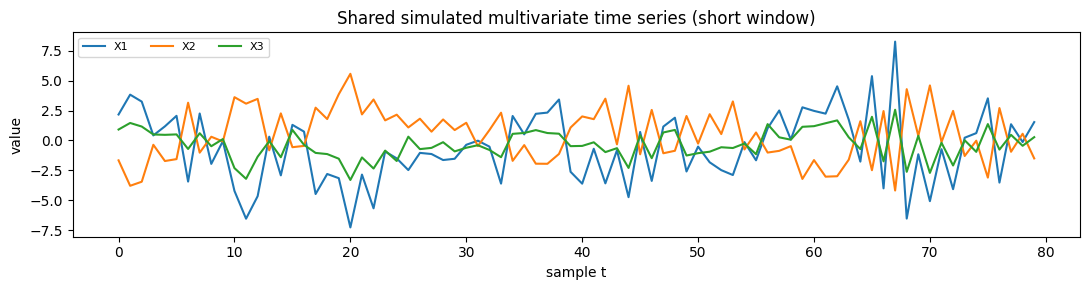

In [2]:
data=simulate_svar(**cfg)
T,d=data.X.shape; p=cfg['p']
print(f'T={T}, d={d}, p={p}')
print(f'companion spectral radius={data.spectral_radius:.6g}')
print(f'cond(I-W0)={data.condition_number:.6g}')
window=min(80,T); fig,ax=plt.subplots(figsize=(11,3))
ax.plot(np.arange(window),data.X[:window]); ax.set(xlabel='sample t',ylabel='value',title='Shared simulated multivariate time series (short window)')
ax.legend([f'X{j+1}' for j in range(d)],ncol=d,fontsize=8); plt.tight_layout()

## Fit both methodsOur estimator uses `k=0`. DYNOTEARS is called only through the existing isolated-subprocess adapter.

In [3]:
ours=fit_dynamic_latent(data.X,p,k=0,lambda_0=.05,lambda_lag=.02,max_outer_iter=6,inner_max_iter=60,random_state=cfg['seed'],**thresholds)
dyno=fit_dynotears(data.X,p=p,python_executable=dynotears_python,lambda_w=.05,lambda_a=.05,max_iter=100,w_threshold=0.)
print('DYNOTEARS environment metadata:')
for key in ('backend','causalnex_version','python_version','p','d'): print(f'  {key}: {dyno.diagnostics.get(key)}')

DYNOTEARS environment metadata:
  backend: official CausalNex subprocess
  causalnex_version: 0.12.1
  python_version: 3.10.11
  p: 2
  d: 3


## Weighted structural matricesAll panels use source variables on rows and target variables on columns. No method is transposed. Panels comparing the same quantity share one color range.

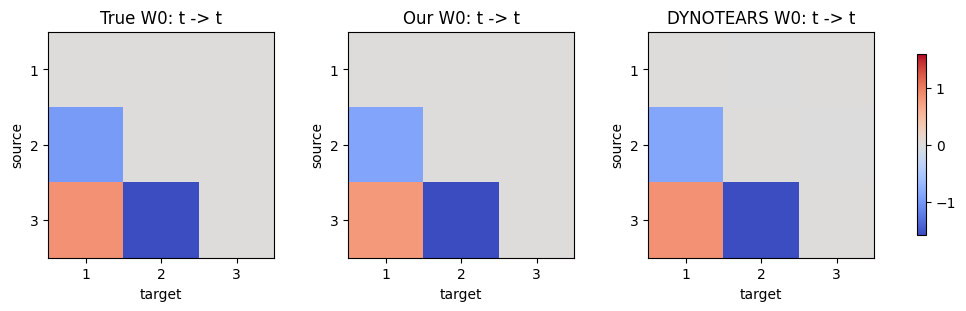

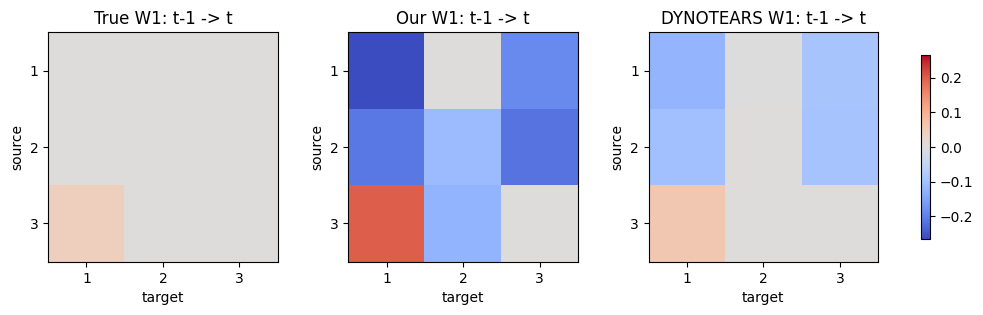

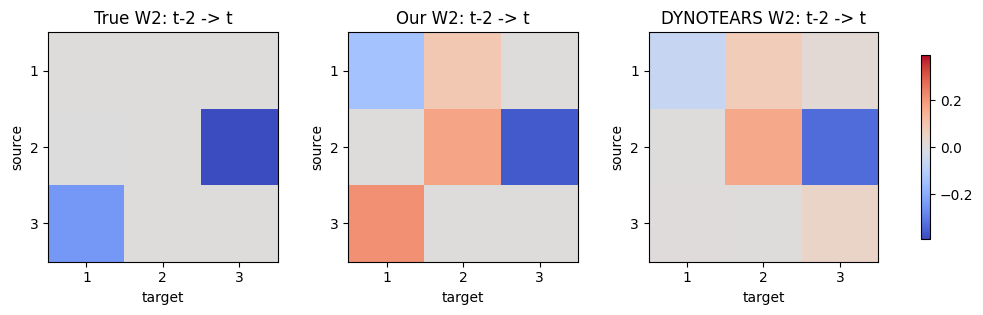

In [4]:
def matrix_triplet(truth,our_est,baseline,title):
    mats=[np.asarray(truth),np.asarray(our_est),np.asarray(baseline)]; limit=max(np.max(np.abs(m)) for m in mats) or 1
    fig,axes=plt.subplots(1,3,figsize=(10,3),constrained_layout=True)
    for ax,m,label in zip(axes,mats,[f'True {title}',f'Our {title}',f'DYNOTEARS {title}']):
        im=ax.imshow(m,cmap='coolwarm',vmin=-limit,vmax=limit,origin='upper'); ax.set_title(label); ax.set(xlabel='target',ylabel='source'); ax.set_xticks(range(d),range(1,d+1)); ax.set_yticks(range(d),range(1,d+1))
    fig.colorbar(im,ax=axes,shrink=.8); plt.show()
matrix_triplet(data.W0_true,ours.W0,dyno.W0,'W0: t -> t')
for tau in range(1,p+1): matrix_triplet(data.W_lags_true[tau-1],ours.W_lags[tau-1],dyno.W_lags[tau-1],f'W{tau}: t-{tau} -> t')

## Support recoveryEncoded cells: TN = 0, TP = 1, FP = 2, FN = 3. Support thresholds are the configured notebook thresholds.

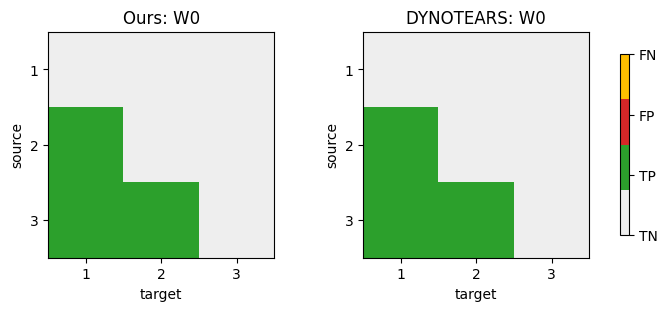

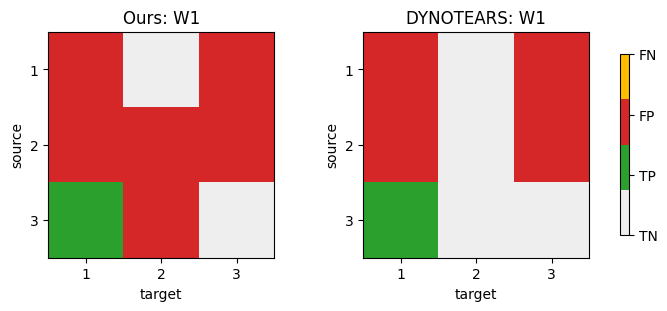

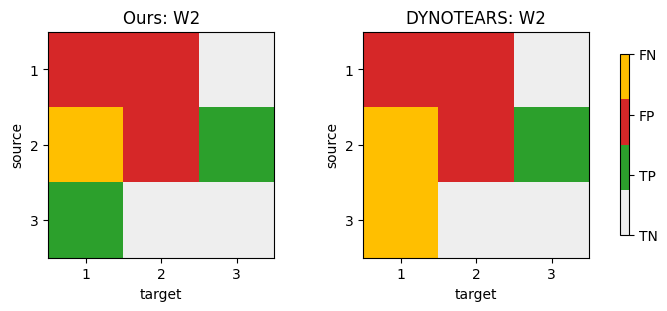

In [5]:
from matplotlib.colors import ListedColormap
error_cmap=ListedColormap(['#eeeeee','#2ca02c','#d62728','#ffbf00'])
def encoded_support(truth,estimate,threshold):
    t=np.abs(truth)>0; q=np.abs(estimate)>threshold; return np.select([t&q,~t&q,t&~q],[1,2,3],default=0)
def support_pair(truth,our_est,baseline,title,threshold):
    fig,axes=plt.subplots(1,2,figsize=(7,3),constrained_layout=True)
    for ax,m,label in zip(axes,[encoded_support(truth,our_est,threshold),encoded_support(truth,baseline,threshold)],[f'Ours: {title}',f'DYNOTEARS: {title}']):
        im=ax.imshow(m,cmap=error_cmap,vmin=0,vmax=3); ax.set_title(label); ax.set(xlabel='target',ylabel='source'); ax.set_xticks(range(d),range(1,d+1)); ax.set_yticks(range(d),range(1,d+1))
    cb=fig.colorbar(im,ax=axes,ticks=range(4),shrink=.8); cb.ax.set_yticklabels(['TN','TP','FP','FN']); plt.show()
support_pair(data.W0_true,ours.W0,dyno.W0,'W0',thresholds['w0_threshold'])
for tau in range(1,p+1): support_pair(data.W_lags_true[tau-1],ours.W_lags[tau-1],dyno.W_lags[tau-1],f'W{tau}',thresholds['wlag_threshold'])

## Directly comparable metrics

In [6]:
import pandas as pd
metrics={}
for name,result in [('ours',ours),('dynotears',dyno)]: metrics[name]=dynamic_metrics(data.W0_true,data.W_lags_true,result.W0,result.W_lags,data.X,**thresholds)
cols={'precision':'precision','recall':'recall','f1':'F1','shd':'SHD','weight_rmse':'weight RMSE','nnz':'predicted edges'}
display(pd.DataFrame({name:{label:m['W0'][key] for key,label in cols.items()} for name,m in metrics.items()}).T)
for tau in range(p):
    print(f'Lag {tau+1}: W{tau+1}, t-{tau+1} -> t')
    display(pd.DataFrame({name:{label:m['lags'][tau][key] for key,label in cols.items()} for name,m in metrics.items()}).T)
lag_cols={k:v for k,v in cols.items() if k!='nnz'}
print('Aggregate lag metrics')
display(pd.DataFrame({name:{label:m['lag_aggregate'][key] for key,label in lag_cols.items()} for name,m in metrics.items()}).T)

,precision,recall,F1,SHD,weight RMSE,predicted edges
ours,1.0,1.0,1.0,0.0,0.037870,3.0
dynotears,1.0,1.0,1.0,0.0,0.036529,3.0


Lag 1: W1, t-1 -> t


,precision,recall,F1,SHD,weight RMSE,predicted edges
ours,0.142857,1.0,0.250000,6.0,0.165843,7.0
dynotears,0.200000,1.0,0.333333,4.0,0.068311,5.0


Lag 2: W2, t-2 -> t


,precision,recall,F1,SHD,weight RMSE,predicted edges
ours,0.40,0.666667,0.500000,4.0,0.173060,5.0
dynotears,0.25,0.333333,0.285714,5.0,0.107626,4.0


Aggregate lag metrics


,precision,recall,F1,SHD,weight RMSE
ours,0.250000,0.75,0.375000,10.0,0.169490
dynotears,0.222222,0.50,0.307692,9.0,0.090138


## Our optimizer diagnostics and runtimeDYNOTEARS does not expose an equivalent iteration history through the official adapter, so only our augmented-Lagrangian history is plotted.

,seconds
our optimization runtime,0.279861
DYNOTEARS worker optimization runtime,0.595489
DYNOTEARS total subprocess wall time,8.919956


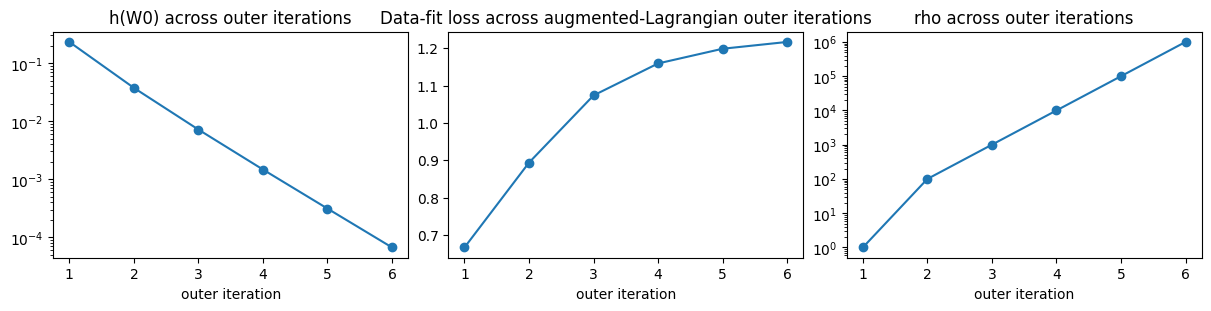

In [7]:
history=ours.diagnostics['history']; outer=[r['outer_iter'] for r in history]
fig,axes=plt.subplots(1,3,figsize=(12,3),constrained_layout=True)
axes[0].semilogy(outer,[max(r['h'],1e-18) for r in history],'o-'); axes[0].set_title('h(W0) across outer iterations')
axes[1].plot(outer,[r['fit_loss'] for r in history],'o-'); axes[1].set_title('Data-fit loss across augmented-Lagrangian outer iterations')
axes[2].semilogy(outer,[r['rho'] for r in history],'o-'); axes[2].set_title('rho across outer iterations')
for ax in axes: ax.set_xlabel('outer iteration')
worker=dyno.diagnostics.get('runtime_seconds',np.nan); wall=dyno.diagnostics.get('wall_runtime_seconds',dyno.runtime_seconds)
display(pd.DataFrame({'seconds':{'our optimization runtime':ours.runtime_seconds,'DYNOTEARS worker optimization runtime':worker,'DYNOTEARS total subprocess wall time':wall}}))

## Comparison summary

In [8]:
summary={}
for name,m in metrics.items():
    result=ours if name=='ours' else dyno
    summary[name]={'W0 F1':m['W0']['f1'],'W0 SHD':m['W0']['shd'],'lag F1':m['lag_aggregate']['f1'],'lag SHD':m['lag_aggregate']['shd'],'W0 RMSE':m['W0']['weight_rmse'],'lag RMSE':m['lag_aggregate']['weight_rmse'],'runtime':result.runtime_seconds}
display(pd.DataFrame(summary).T)

,W0 F1,W0 SHD,lag F1,lag SHD,W0 RMSE,lag RMSE,runtime
ours,1.0,0.0,0.375000,10.0,0.037870,0.169490,0.279861
dynotears,1.0,0.0,0.307692,9.0,0.036529,0.090138,8.919956
